# Loan Approval Prediction using Logistic Regression

## Project Overview

This project aims to predict whether a loan application will be approved based on applicant financial and employment information. A Logistic Regression model is used to classify loan applications as Approved or Not Approved.

### Objective
- Analyze factors affecting loan approval.
- Build a predictive model using Logistic Regression.
- Evaluate model performance using classification metrics.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [1]:
## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
## Load Dataset

In [55]:
import pandas as pd
df = pd.read_csv('loan_approval - loan_approval.csv')
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


## Dataset Overview
Understanding the structure, dimensions, and data types of the dataset.

In [56]:
df.shape

(2000, 8)

In [57]:
df.dtypes

name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object

## Data Quality Checks

Checking for missing values and duplicate records to ensure data quality before analysis.

In [58]:
df.isnull().sum()

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

In [59]:
df.duplicated().sum()

np.int64(0)

 After checking the dataset, no missing values were found in any column. Therefore, no missing value treatment was required.

## Exploratory Data Analysis
Analyzing key variables and identifying patterns related to loan approval.

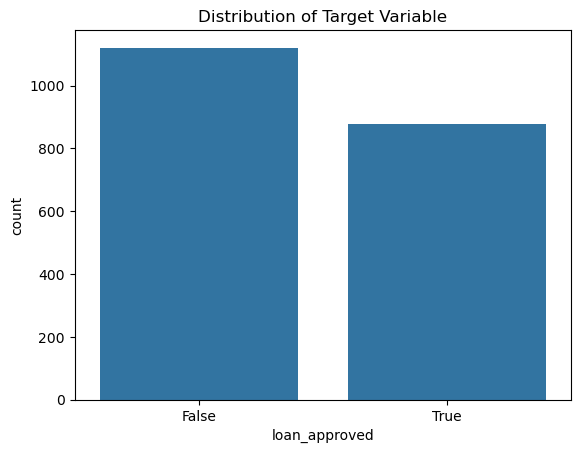

In [60]:
sns.countplot(x='loan_approved',data=df)
plt.title("Distribution of Target Variable")
plt.show()

The distribution plot of the target variable (loan_approved) shows the frequency of approved and non-approved loans in the dataset. The dataset contains slightly more non-approved loans (0) than approved loans (1). This indicates a moderate imbalance in the target classes.

### Credit Score vs Loan Approval

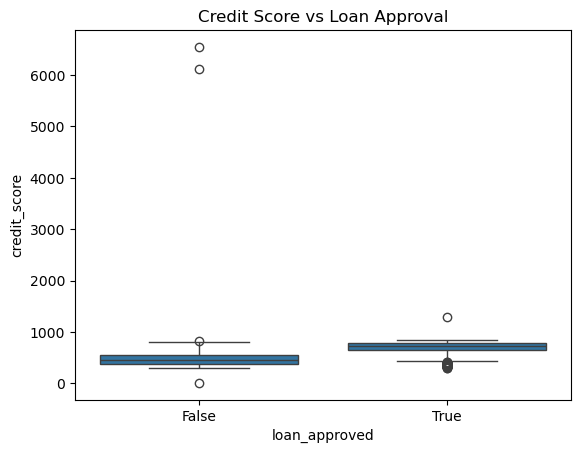

In [61]:
sns.boxplot(x='loan_approved', y='credit_score',data=df)
plt.title('Credit Score vs Loan Approval')
plt.show()

**Interpretation**

The boxplot compares credit scores between approved and non-approved loan applications. 

Applicants with approved loans generally have higher credit scores than applicants whose loans were not approved.

The median credit score for approved loans is noticeably higher, indicating a positive relationship between credit score and loan approval. Although a few extreme outliers are present in the dataset, the overall trend suggests that credit score is an important factor influencing loan approval decisions.


### Points vs Loan Approval

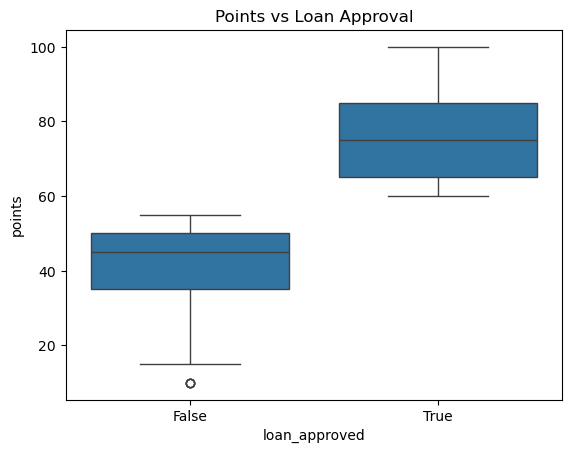

In [62]:
sns.boxplot(x='loan_approved', y='points', data=df)
plt.title('Points vs Loan Approval')
plt.show()

**Interpretation**

The boxplot illustrates the relationship between Points and loan approval status. 

Applicants with approved loans generally have significantly higher Points scores than those whose loans were not approved.

The median Points score for approved loans is substantially higher, and there is minimal overlap between the two groups. This indicates a strong positive relationship between Points and loan approval, suggesting that Points is one of the most influential factors in determining loan approval decisions.


### Income vs Loan Approval

<Axes: xlabel='loan_approved', ylabel='income'>

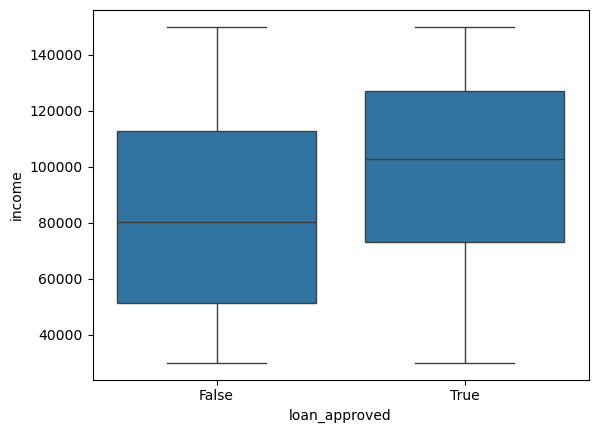

In [63]:
sns.boxplot(x='loan_approved',y='income',data=df)

**Interpretation**

The boxplot shows the relationship between income and loan_approved.

False represents loans that were not approved.

True represents loans that were approved.

From the graph:

Applicants with approved loans (True) generally have higher income compared to applicants whose loans were not approved (False).
The median income for approved loans is higher.
This suggests that income positively influences loan approval.

### Years of Employment vs Loan Approval

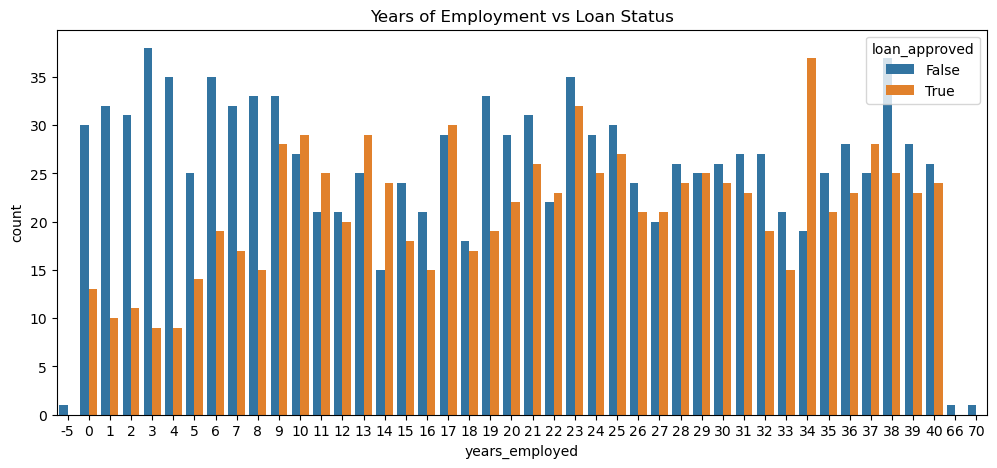

In [64]:
plt.figure(figsize=(12,5))
sns.countplot(x='years_employed', hue='loan_approved', data=df)
plt.title("Years of Employment vs Loan Status")
plt.show()

For lower years of employment (around 0–8 years), non-approved loans are generally higher than approved loans.
As years of employment increase, the number of approved loans also increases in several categories.
Applicants with stable and longer employment history appear to have better chances of loan approval.

## Data Preprocessing: Outlier Detection and Treatment

Outliers in numerical features were identified using the Interquartile Range (IQR) method. Detected outliers were capped at the lower and upper IQR bounds to reduce their impact on model performance while preserving the overall data distribution.

In [65]:
nums_culmns = df.select_dtypes(include=['int64', 'float64']).columns
for col in nums_culmns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(col, ":", len(outliers), "outliers")

income : 0 outliers
credit_score : 3 outliers
loan_amount : 0 outliers
years_employed : 2 outliers
points : 0 outliers


In [66]:
import numpy as np
df[col] = np.where(df[col] < lower_bound,
                       lower_bound,
                       df[col])

    # Capping upper outliers
df[col] = np.where(df[col] > upper_bound,
                       upper_bound,
                       df[col])

## Data Preparation for Modeling

The target variable was converted into a numerical format suitable for machine learning algorithms. Unnecessary columns were removed to improve model performance and simplify feature selection.

In [67]:
df['loan_approved'] = df['loan_approved'].astype(int)

In [68]:
X = df.drop(['name','city','loan_approved'],axis=1)
y = df['loan_approved']

## Feature Selection and Train-Test Split

The dataset was divided into independent variables (X) and the target variable (y). A train-test split was performed to evaluate model performance on unseen data.

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Feature Scaling

Numerical features were standardized using StandardScaler to ensure all variables were on a comparable scale before model training.

In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Model Development

In [71]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [72]:
y_pred = model.predict(X_test_scaled)

print(y_pred)

[0 1 1 1 1 1 0 1 0 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 1 1 0 1 0 0 1 0 1 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 0 0 1 0 0 1 0 1 1 0 0 1 0
 1 0 1 1 0 1 1 1 1 1 0 0 1 1 1 0 0 1 1 1 0 1 0 1 1 1 1 0 0 1 0 0 0 0 1 0 0
 0 0 0 0 0 1 0 0 0 1 1 0 0 1 1 1 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 1 0 0 1 0 1
 0 0 0 0 0 1 1 0 0 0 1 0 0 1 0 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 0 1 1 1 1 1 0
 0 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 0 1 1 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 1 0 1 0 0 0 0 1 0 0 1
 1 0 1 0 0 1 0 0 1 0 1 1 1 1 0 0 1 1 1 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0 0 1 1
 1 0 1 1 0 1 0 0 0 0 0 1 0 1 1 0 1 1 0 1 1 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1
 0 0 0 1 1 1 1 0 0 1 1 0 0 1 1 0 1 0 1 0 1 0 1 0 1 1 0 1 1 1 1 0 1 1 1 0 1
 1 1 0 1 1 0 0 1 0 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 0 0 1 1 1]


The Logistic Regression model was used to predict loan approval status for the testing dataset. The predicted values were stored in y_pred, where 1 represents approved loans and 0 represents non-approved loans. These predictions are used to evaluate the performance of the classification model.

## Model Evaluation

In [73]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[217   0]
 [  0 183]]


**Interpretation**

217 represents True Negatives (TN).
The model correctly predicted 217 non-approved loans.

183 represents True Positives (TP).
The model correctly predicted 183 approved loans.

0 represents False Positives (FP).
No non-approved loans were incorrectly predicted as approved.

0 represents False Negatives (FN).
 No approved loans were incorrectly predicted as non-approved.

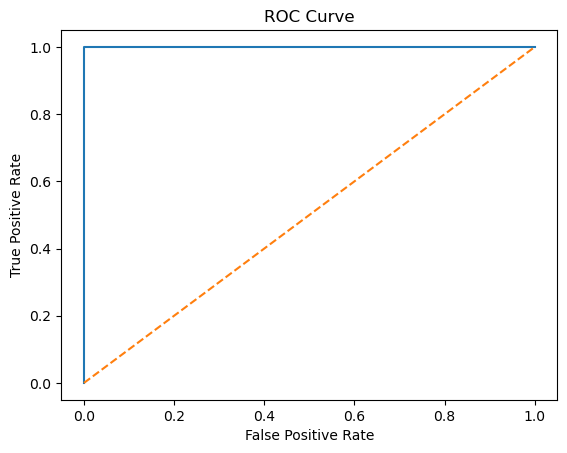

In [74]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test_scaled)[:,1]


fpr, tpr, thresholds = roc_curve(y_test, y_prob)


plt.plot(fpr, tpr)


plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

The ROC curve is close to the top-left corner, indicating excellent classification performance. The model achieves a high True Positive Rate with a very low False Positive Rate. Since the ROC curve is far above the diagonal line, the Logistic Regression model performs significantly better than random classification.

In [75]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 1.0


The calculated AUC score is 1.0, which indicates perfect classification performance by the Logistic Regression model. The model is able to completely distinguish between approved and non-approved loans without any classification errors. This shows that the model performs exceptionally well on the testing dataset.

# Conclusion

This project successfully developed a Logistic Regression model to predict loan approval status using applicant financial and employment information.

Key findings:
- Points was the strongest predictor of loan approval, showing a strong positive correlation with the target variable.
- Credit Score demonstrated a moderate positive relationship with loan approval, indicating that applicants with higher credit scores were more likely   to be approved.
- Income showed a positive but relatively weaker influence on loan approval decisions.
- Years of Employment had only a weak positive relationship with loan approval in this dataset.
- Loan Amount exhibited a weak negative relationship with loan approval, suggesting that larger loan requests were slightly less likely to be approved.
- The Logistic Regression model achieved excellent classification performance, indicating that the selected features effectively distinguish approved    and non-approved loan applications.

The model demonstrates how machine learning can support financial institutions in making faster and more data-driven lending decisions.